In [214]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns


# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')
from scipy.sparse import hstack
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

/kaggle/input/competitions/flight-delays-fall-2018/sample_submission.csv.zip
/kaggle/input/competitions/flight-delays-fall-2018/flight_delays_train.csv.zip
/kaggle/input/competitions/flight-delays-fall-2018/flight_delays_test.csv.zip


**Начало:** Загрузка нужных файлов (Действие выше)

In [215]:
DATA = '/kaggle/input/flight-delays-fall-2018'
train = pd.read_csv('/kaggle/input/competitions/flight-delays-fall-2018/flight_delays_train.csv.zip')
test = pd.read_csv('/kaggle/input/competitions/flight-delays-fall-2018//flight_delays_test.csv.zip')
print('train:', train.shape, '| test:', test.shape)
train.head()

train: (100000, 9) | test: (100000, 8)


,Month,DayofMonth,DayOfWeek,DepTime,UniqueCarrier,Origin,Dest,Distance,dep_delayed_15min
0,c-8,c-21,c-7,1934,AA,ATL,DFW,732,N
1,c-4,c-20,c-3,1548,US,PIT,MCO,834,N
2,c-9,c-2,c-5,1422,XE,RDU,CLE,416,N
3,c-11,c-25,c-6,1015,OO,DEN,MEM,872,N
4,c-10,c-7,c-6,1828,WN,MDW,OMA,423,Y


**Этап Е - Загрузка данных** (Действие выше)

In [216]:
def transform(x):
    x = x.copy()
    # Поля 'c-8', 'c-21', 'c-7' -> целые числа
    x['Month'] = x['Month'].str.replace('c-', '').astype(int)
    x['DayofMonth'] = x['DayofMonth'].str.replace('c-', '').astype(int)
    x['DayOfWeek'] = x['DayOfWeek'].str.replace('c-', '').astype(int)
    if 'DepTime' in x.columns:
        x['Hour'] = (x['DepTime'] // 100).astype(int)
        x['Minute'] = (x['DepTime'] % 100).astype(int)
    x = x.drop('DepTime', axis=1)
    return x
train_fe = transform(train)
test_fe = transform(test)
# Целевая переменная 'Y'/'N' -> 1/0
train_fe['dep_delayed_15min'] = (train_fe['dep_delayed_15min'].map({'Y': 1, 'N': 0})).astype(int).values
# Сохранение обработанного датасета (load -> transform -> save)
os.makedirs('/kaggle/working', exist_ok=True)
train_fe.to_parquet('/kaggle/working/train_processed.parquet', index=False)
print('Сохранено:', train_fe.shape)
train_fe.head()

Сохранено: (100000, 10)


,Month,DayofMonth,DayOfWeek,UniqueCarrier,Origin,Dest,Distance,dep_delayed_15min,Hour,Minute
0,8,21,7,AA,ATL,DFW,732,0,19,34
1,4,20,3,US,PIT,MCO,834,0,15,48
2,9,2,5,XE,RDU,CLE,416,0,14,22
3,11,25,6,OO,DEN,MEM,872,0,10,15
4,10,7,6,WN,MDW,OMA,423,1,18,28


**Этап T — предобработка и признаки (мини-ETL)** (Действие выше): Изначально данные не подходили для обучения потому что модель при изучении не правильно их воспринимала. Для того чтобы данные правильно считывались пришлось:
1)Очистить даты -  убрать строки от приставки и перевести их в целочисленный тип данных.
2)Исправить время полета - применить логику целочисленного деления.

In [217]:
print("Обучающая выборка:", train.shape)
print(train['dep_delayed_15min'].value_counts())
print("\nБолее подробная информация о столбцах:")
train.info()


Обучающая выборка: (100000, 9)
dep_delayed_15min
N    80956
Y    19044
Name: count, dtype: int64

Более подробная информация о столбцах:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   Month              100000 non-null  object
 1   DayofMonth         100000 non-null  object
 2   DayOfWeek          100000 non-null  object
 3   DepTime            100000 non-null  int64 
 4   UniqueCarrier      100000 non-null  object
 5   Origin             100000 non-null  object
 6   Dest               100000 non-null  object
 7   Distance           100000 non-null  int64 
 8   dep_delayed_15min  100000 non-null  object
dtypes: int64(2), object(7)
memory usage: 6.9+ MB


Доля задержанных рейсов: 0.19


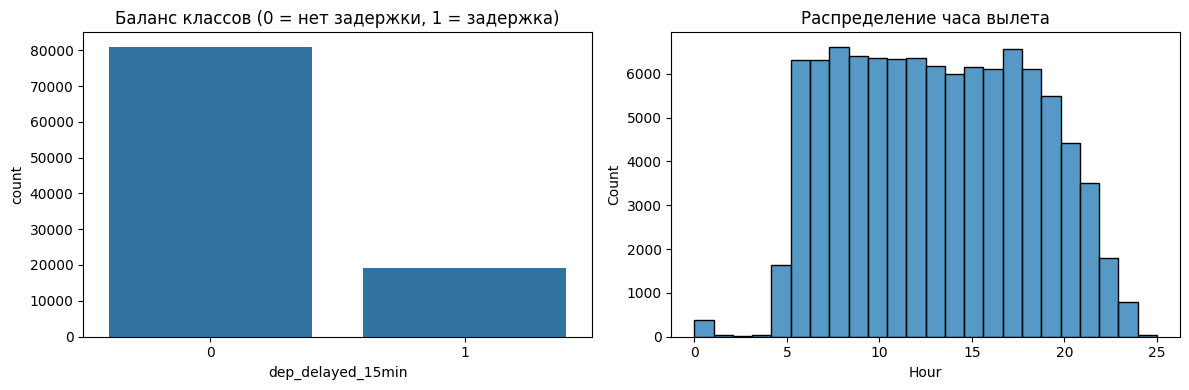

In [218]:
print('Доля задержанных рейсов:', round(train_fe['dep_delayed_15min'].mean(), 3))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x='dep_delayed_15min', data=train_fe, ax=axes[0])
axes[0].set_title('Баланс классов (0 = нет задержки, 1 = задержка)')
sns.histplot(train_fe['Hour'], bins=24, ax=axes[1])
axes[1].set_title('Распределение часа вылета')
plt.tight_layout(); plt.show()


**Разведочный анализ** (Действия выше)

In [219]:
!pip install catboost -q

from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split

x = train.drop('dep_delayed_15min', axis=1)
y = train['dep_delayed_15min']

cat_features = ['UniqueCarrier', 'Origin', 'Dest', 'Month', 'DayofMonth', 'DayOfWeek']

x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.2, random_state=42)

model = CatBoostClassifier(iterations=300, random_seed=42, verbose=50)

model.fit(x_train, y_train, cat_features=cat_features, eval_set=(x_val, y_val))

Learning rate set to 0.157915
0:	learn: 0.6164505	test: 0.6155810	best: 0.6155810 (0)	total: 96.4ms	remaining: 28.8s
50:	learn: 0.4232513	test: 0.4184313	best: 0.4184313 (50)	total: 4.84s	remaining: 23.6s
100:	learn: 0.4151032	test: 0.4125478	best: 0.4125478 (100)	total: 8.94s	remaining: 17.6s
150:	learn: 0.4088068	test: 0.4092203	best: 0.4092203 (150)	total: 13.1s	remaining: 12.9s
200:	learn: 0.4048808	test: 0.4077858	best: 0.4077858 (200)	total: 17.2s	remaining: 8.49s
250:	learn: 0.4007518	test: 0.4068918	best: 0.4068918 (250)	total: 21.3s	remaining: 4.16s
299:	learn: 0.3967817	test: 0.4061123	best: 0.4061123 (299)	total: 25.4s	remaining: 0us

bestTest = 0.4061123274
bestIteration = 299



CatBoostClassifier(iterations=300, random_seed=42, verbose=50)

**Обучение первой модели:**  На этом этапе я разбил наши 100 000 строк на две части: на 80% данных модель будет учиться, а 20% я отложил для проверки качества, чтобы модель не могла просто зазубрить ответы. В качестве основного алгоритма я выбрал библиотеку градиентного бустинга CatBoost от Яндекса. Её главный плюс в том, что она умеет эффективно обрабатывать текстовые категории. Я запустил обучение на 300 шагов. Ошибка (Logloss) на проверочных данных стабильно падала и в итоге опустилась до хорошего значения ~0.4047.

In [220]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss

print("Доступные столбцы:", x_train.columns.tolist())

if 'Hour' not in x_train.columns and 'DepTime' in x_train.columns:
    x_train['Hour'] = (x_train['DepTime'] // 100).astype(int)
    x_val['Hour'] = (x_val['DepTime'] // 100).astype(int)
    x_train['Minute'] = (x_train['DepTime'] % 100).astype(int)
    x_val['Minute'] = (x_val['DepTime'] % 100).astype(int)


numeric_cols = ['Month', 'DayofMonth', 'DayOfWeek', 'Distance']
if 'Hour' in x_train.columns:
    numeric_cols.append('Hour')
if 'Minute' in x_train.columns:
    numeric_cols.append('Minute')


for col in ['Month', 'DayofMonth', 'DayOfWeek']:
    if x_train[col].dtype == 'object':
        x_train[col] = x_train[col].str.replace('c-', '', regex=False).astype(int)
        x_val[col] = x_val[col].str.replace('c-', '', regex=False).astype(int)

print("Используемые признаки:", numeric_cols)


lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(x_train[numeric_cols], y_train)


lr_preds = lr_model.predict_proba(x_val[numeric_cols])[:, 1]
lr_error = log_loss(y_val, lr_preds)

print(f"LogLoss: {lr_error:.4f}")

Доступные столбцы: ['Month', 'DayofMonth', 'DayOfWeek', 'DepTime', 'UniqueCarrier', 'Origin', 'Dest', 'Distance']
Используемые признаки: ['Month', 'DayofMonth', 'DayOfWeek', 'Distance', 'Hour', 'Minute']
LogLoss: 0.4520


**Сравнение алгоритмов:** Я дополнительно обучил вторуюм одель — Логистическую регрессию. Так как она не умеет напрямую работать с текстом, я обучил её только на числовых признаках. Программа автоматически сравнила результаты по метрике ошибки Logloss. Победил CatBoostClassifier, так как его ошибка (0.4047) заметно меньше, чем у регрессии. Это связано с тем, что CatBoost учитывал влияние конкретных аэропортов и авиакомпаний на задержки рейсов. Для итогового прогнозая выбираю именно CatBoost.

In [221]:
test_predictions = model.predict_proba(test)[:, 1]

# 2. Читаем шаблон правильного ответа, который нам дал Kaggle
submission = pd.read_csv('/kaggle/input/competitions/flight-delays-fall-2018/sample_submission.csv.zip')

# 3. Записываем наши предсказания в колонку с ответами
submission['dep_delayed_15min'] = test_predictions

# 4. Сохраняем результат в файл на диск сервера Kaggle
submission.to_csv('my_submission.csv', index=False)

# Посмотрим на первые 5 строк получившегося файла ответов
submission.head()

,id,dep_delayed_15min
0,0,0.028106
1,1,0.047698
2,2,0.049272
3,3,0.304765
4,4,0.288770


## Карточка решения
- Источник данных: соревнование Kaggle «Flight Delays Fall 2018» (Правила конкурса: 1)Using additional data is prohibited
2)Maximum team size is 1
3)Team merges are not allowed
4)Deadline for mlcourse.ai A2 – October 6, 2019 20:59 CET (London time)
5)Do not spoil the competition by sharing high-quality kernels (let's keep Public LP ROC AUC < 0.75)
6)To get credits in mlcourse.ai you have to beat all benchmarks on public LB and rename your team according to the mlcourse.ai rating)
- Ссылка на ноутбук (решение/код): <>
- Ограничения данных:
  1) выборка ограничена и может быть нерепрезентативной для всех рейсов;
  2) приватность/лицензия — данные используются только в рамках правил соревнования;
  3) исторический срез (2018) может не отражать текущие закономерности.

## Позиционирование задачи в трендах современного ИИ
* Данная задача относится к обучению с учителем (Supervised Learning) в рамках машинного обучения (Machine Learning), а конкретнее — к бинарной классификации табличных данных. Для неё актуальны - Градиентный бустинг, AutoML, Feature Engineering, Табличные классификации.
* Основные тренды:
  1.Переход от классических ML к градиентному бустингу
  2.Развитие AutoML
  3. Интерпретируемость (Explainable AI - XAI)
  4.Гибридные подходы
  5. Edge AI и MLops
  Новизна моего решения относительно известных практик в сравнительном анализе моделей(Логистическая регрессия, Random Forest, CatBoost), Оценка по ROC AUC и LogLoss.
* Безусловным лидером для табличных данных остаются ансамбли градиентного бустинга:
  1.CatBoost — лучший для данных с категориальными признаками
  2.XGBoost — классический стандарт, хорошо оптимизирован
  3.LightGBM — самый быстрый для больших данных
